### Image Captioning Model
In the realm of multi-modal large language models (MLLMs), image-to-text and text-to-image models are among one of the most commonly seen applications. Can we generate a caption given an image and vice versa? We saw in the presentation that transformer architectures are general sequence-processing architectures that can process both images and text. In this lesson, we will learn how to build a vision-text transformer architecture yourself and compare the DIY-transformer performance against a pre-trained image captioning model. 

### ![Dolly](https://files.training.databricks.com/images/llm/dolly_small.png) Learning Objectives
- Connect pretrained vision and text models as a single transformer architecture for image captioning
- Train your image captioning model
- Qualitatively inspect the quality of the caption generated
- Compare the output with an pretrained image captioning model

We are going to use `sbu_captions` as our dataset to train our own image captioning model. 
`sbu_captions` contains 1 million pairs of image urls and captions. Visit [this link](https://huggingface.co/datasets/sbu_captions) to view their dataset on Hugging Face Datasets hub.

In [1]:
#!pip install transformers transformers[torch] datasets

In [2]:
#!pip install transformers==4.45.2

In [3]:
from datasets import load_dataset

data = load_dataset("sbu_captions", split="train", trust_remote_code=True).shuffle(seed=42)
data

Dataset({
    features: ['image_url', 'user_id', 'caption'],
    num_rows: 1000000
})

In [4]:
data[0]

{'image_url': 'http://static.flickr.com/3149/2803944157_1006b92fc0.jpg',
 'user_id': '37266013@N00',
 'caption': 'St. Martins - view of the beach from the field above the cliff'}

## Initialize an image-to-text model
In the following section, we are going to use [Vision Encoder Decoder Model](https://huggingface.co/docs/transformers/model_doc/vision-encoder-decoder) to initialize our image-to-text model. The encoder would be a transformer-based vision model to process the images and the decoder is a language model to generate the caption. Then, we will connect both the vision and language model together and further train the vision-language model on a subset of `sbu_captions`. 

### Define data processing function
First, we will need to have a function to properly process our training dataset that contains the image urls and respective captions.

In [5]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import requests
from io import BytesIO

In [6]:
class ProcessDataset(Dataset):
    def __init__(self, df, tokenizer,feature_extractor, decoder_max_length=20):
        self.df = df
        self.tokenizer = tokenizer # this is for language model 
        self.feature_extractor = feature_extractor # this is for vision model 
        self.decoder_max_length = decoder_max_length # this is for caption output

    def __len__(self):
        # this is necessary so that HuggingFace won't complain that the dataset doesn't have __len__ method 
        # when it starts training
        return len(self.df)

    def __getitem__(self, idx):
        # this is another method name that HuggingFace expects 
        # get file name + text 
        img_path = self.df["image_url"][idx]
        caption = self.df["caption"][idx]
        
        # process image 
        response = requests.get(img_path)
        image = Image.open(BytesIO(response.content))
        pixel_values = self.feature_extractor(image, return_tensors="pt").pixel_values

        # labels here refer to each token in the caption
        labels = self.tokenizer(caption, 
                                truncation=True,
                                padding="max_length", 
                                max_length=self.decoder_max_length).input_ids

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

### Initialize tokenizer and image feature extractor
Next, we will initialize our tokenizer to process text and feature extractor to process images respectively. After this, we are ready to pass our training dataset for processing.

In [7]:
from transformers import AutoTokenizer, ViTFeatureExtractor

tokenizer = AutoTokenizer.from_pretrained("gpt2")
# GPT2 doesn't have a pad token 
tokenizer.pad_token = tokenizer.eos_token

feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [129]:
train_dataset = ProcessDataset(df=data[:400000],
                               tokenizer=tokenizer,
                               feature_extractor=feature_extractor)

It is very important that we understand what is happening in Dataset class.
In the following section we will execute each of the step manually and see what exactly it does

In [130]:
df = data[:200000]

In [131]:
len(df['image_url'])

200000

In [132]:
caption = df["caption"][0]
caption

'St. Martins - view of the beach from the field above the cliff'

In [133]:
img_path = df["image_url"][0]
img_path

'http://static.flickr.com/3149/2803944157_1006b92fc0.jpg'

In [134]:
response = requests.get(img_path)
response

<Response [200]>

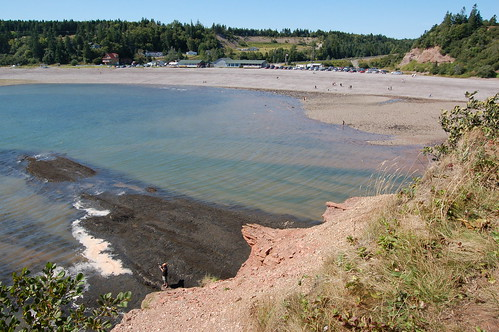

In [135]:
image = Image.open(BytesIO(response.content))
image

In [136]:
image.size

(499, 332)

In [137]:
pixel_values = feature_extractor(image, return_tensors="pt").pixel_values
pixel_values.shape, pixel_values
#This guy is resizing, and normalizing the pixel values and then coverting into tensor after adding a batch dimension

(torch.Size([1, 3, 224, 224]),
 tensor([[[[ 0.2314,  0.2314,  0.2392,  ...,  0.1137,  0.1216,  0.1294],
           [ 0.2471,  0.2471,  0.2471,  ...,  0.1216,  0.1373,  0.1451],
           [ 0.2471,  0.2471,  0.2471,  ...,  0.1451,  0.1451,  0.1529],
           ...,
           [-0.8118, -0.6627, -0.7725,  ...,  0.3098,  0.2863,  0.2706],
           [-0.7647, -0.7098, -0.8431,  ...,  0.2157,  0.2157,  0.2235],
           [-0.5216, -0.6314, -0.8118,  ...,  0.1765,  0.1373,  0.1059]],
 
          [[ 0.5922,  0.5922,  0.6000,  ...,  0.5216,  0.5137,  0.5059],
           [ 0.6078,  0.6078,  0.6078,  ...,  0.5294,  0.5294,  0.5216],
           [ 0.6078,  0.6078,  0.6078,  ...,  0.5294,  0.5294,  0.5294],
           ...,
           [-0.7412, -0.6549, -0.7412,  ..., -0.0039, -0.0275, -0.0510],
           [-0.6941, -0.7176, -0.7961,  ..., -0.1137, -0.0980, -0.0588],
           [-0.4588, -0.6314, -0.7569,  ..., -0.1451, -0.1608, -0.1373]],
 
          [[ 0.8588,  0.8588,  0.8667,  ...,  0.8353,  

In [138]:
pixel_values.squeeze().shape

torch.Size([3, 224, 224])

In [139]:
labels = tokenizer(caption,
                   truncation=True,
                   padding="max_length", 
                   max_length=20).input_ids
torch.tensor(labels)

tensor([ 1273,    13,  3981,  1040,   532,  1570,   286,   262, 10481,   422,
          262,  2214,  2029,   262, 19516, 50256, 50256, 50256, 50256, 50256])

### Using VisionEncoderDecoder 
Here, we will finally use `VisionEncoderDecoder` to connect our pretrained image and text models of choice. 

In [140]:
from transformers import VisionEncoderDecoderModel

In [141]:
image_model = "google/vit-base-patch16-224-in21k"
text_model = "gpt2"

In [142]:
model = VisionEncoderDecoderModel.from_encoder_decoder_pretrained(
    encoder_pretrained_model_name_or_path=image_model, 
    decoder_pretrained_model_name_or_path=text_model, 
    tie_encoder_decoder=True)

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.crossat

In [143]:
!pip install torchinfo
from torchinfo import summary

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [144]:
model

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(i

In [145]:
summary(model)

Layer (type:depth-idx)                                       Param #
VisionEncoderDecoderModel                                    --
├─ViTModel: 1-1                                              --
│    └─ViTEmbeddings: 2-1                                    152,064
│    │    └─ViTPatchEmbeddings: 3-1                          590,592
│    │    └─Dropout: 3-2                                     --
│    └─ViTEncoder: 2-2                                       --
│    │    └─ModuleList: 3-3                                  85,054,464
│    └─LayerNorm: 2-3                                        1,536
│    └─ViTPooler: 2-4                                        --
│    │    └─Linear: 3-4                                      590,592
│    │    └─Tanh: 3-5                                        --
├─GPT2LMHeadModel: 1-2                                       --
│    └─GPT2Model: 2-5                                        --
│    │    └─Embedding: 3-6                                   38,597,376
│

In [146]:
model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id

In [147]:
model.config.vocab_size = model.config.decoder.vocab_size
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3 # this determines a sequence of N words that cannot be repeated 
model.config.length_penalty = 2.0

In [148]:
model.config.num_beams = 2

In [149]:
model.config

VisionEncoderDecoderConfig {
  "decoder": {
    "_name_or_path": "gpt2",
    "activation_function": "gelu_new",
    "add_cross_attention": true,
    "architectures": [
      "GPT2LMHeadModel"
    ],
    "attn_pdrop": 0.1,
    "bad_words_ids": null,
    "begin_suppress_tokens": null,
    "bos_token_id": 50256,
    "chunk_size_feed_forward": 0,
    "cross_attention_hidden_size": null,
    "decoder_start_token_id": null,
    "diversity_penalty": 0.0,
    "do_sample": false,
    "early_stopping": false,
    "embd_pdrop": 0.1,
    "encoder_no_repeat_ngram_size": 0,
    "eos_token_id": 50256,
    "exponential_decay_length_penalty": null,
    "finetuning_task": null,
    "forced_bos_token_id": null,
    "forced_eos_token_id": null,
    "id2label": {
      "0": "LABEL_0",
      "1": "LABEL_1"
    },
    "initializer_range": 0.02,
    "is_decoder": true,
    "is_encoder_decoder": false,
    "label2id": {
      "LABEL_0": 0,
      "LABEL_1": 1
    },
    "layer_norm_epsilon": 1e-05,
    "length_

In [150]:
# For decoder only 
model.decoder.num_beams = 4
model.decoder.max_length = 20 

## Train image-captioning model

In [151]:
from transformers import Trainer, TrainingArguments
from transformers import default_data_collator
import os

In [167]:
BATCH_SIZE = 16
TRAIN_EPOCHS = 10000

output_directory = os.path.join("captioning_outputs")

training_args = TrainingArguments(
    output_dir=output_directory,
    per_device_train_batch_size=BATCH_SIZE,
    do_train=True,
    num_train_epochs=TRAIN_EPOCHS, # number of passes to see the entire dataset 
    overwrite_output_dir=True,
    #no_cuda=NO_CUDA, # Not using GPU when on CPU-only cluster
    dataloader_pin_memory=False, # this specifies whether you want to pin memory in data loaders or not
    #eval_strategy="epoch",
    save_strategy="no"

)

trainer = Trainer(
    tokenizer=feature_extractor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=default_data_collator,
)

In [168]:
trainer.train()

Step,Training Loss
500,0.000200
1000,0.001500
1500,0.000000
2000,0.000000
2500,0.000200
3000,0.000000
3500,0.000000
4000,0.000000
4500,0.000000
5000,0.000000


TrainOutput(global_step=10000, training_loss=9.275760415548575e-05, metrics={'train_runtime': 2187.1335, 'train_samples_per_second': 13.717, 'train_steps_per_second': 4.572, 'total_flos': 5.41391673360384e+18, 'train_loss': 9.275760415548575e-05, 'epoch': 10000.0})

### Generate caption from an image
Now, let's try generating caption from a randomly picked image below.

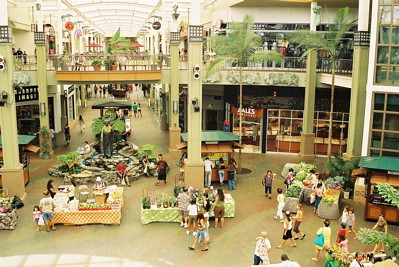

In [169]:
test_img = data[2021]

test_img_path = test_img["image_url"]
test_img_response = requests.get(test_img_path)
test_image = Image.open(BytesIO(test_img_response.content))
display(test_image)

In [171]:
caption = tokenizer.decode(trainer.model.to("cpu").generate(feature_extractor(test_image, return_tensors="pt").pixel_values)[0])
print("--"*20)
print(caption)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


----------------------------------------
<|endoftext|>A butterfly on a flower in Kenya<|endoftext|>


Hmm, you can see that the caption is not really relevant to the image above. What went wrong? There are two possible reasons: 
- Parts of our text decoder weights were not loaded from the pretrained checkpoints. So the best approach would have been to train the decoder separately on the training dataset first and load the fine-tuned decoder. (I do not agree with this as gpt2 is a decoder only model which does not features cross attention. I guess for the purpose of fitting into encoder decoder architecture, they must have custom-made cross atention so that it can interface with vision model else how is it gonna talk to vision model)
- Our image-captioning model needs more fine-tuning time! Try increasing the # of epochs, # of training data samples, and adjust other model hyperparameters if you'd like. 

But now you learned how to plug in your own transformer-based models and connect them as an encoder-decoder model! It would definitely be much easier if we use an existing image captioning model instead. Let's do that next!  

### What if we use an existing image captioning model instead? 
Will the caption generated improve and be more relevant? Let's find out! 
We will be using a new model called `BLIP`, which stands for Bootstrapping Language-Image Pre-training. It's a modeling approach to unify vision-language understanding and generation by [Li et al 2022](https://arxiv.org/abs/2201.12086). It stands out from other vision-language model because: 
Most existing pre-trained models only excel in either understanding-based tasks or generation-based tasks. [...] BLIP effectively utilizes the noisy web data by bootstrapping the captions, where a captioner generates synthetic captions and a filter removes the noisy ones.

The excerpt above is from the paper's abstract. You can also read briefly about BLIP in the [HuggingFace documentation](https://huggingface.co/Salesforce/blip-image-captioning-base).

In [172]:
from transformers import BlipProcessor, BlipForConditionalGeneration

In [173]:
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

#### Conditional image captioning
- In many of the initial vision-language models, adding a prefix text like below "a photo of " is crucial for models to do well.
- the addition of the prefix text makes the caption generation "conditional".

In [174]:
text = "a photo of"
inputs = blip_processor(test_image, text, return_tensors="pt")
print(inputs)

{'pixel_values': tensor([[[[ 1.7844,  1.7552,  1.7698,  ...,  0.7333,  0.6311,  0.6165],
          [ 1.7990,  1.7552,  1.7698,  ...,  0.7771,  0.6457,  0.6019],
          [ 1.7990,  1.7552,  1.7698,  ...,  0.6457,  0.5727,  0.4997],
          ...,
          [ 1.7990,  1.7260,  1.7406,  ...,  1.6822,  1.4924,  0.7333],
          [ 1.7990,  1.7114,  1.6968,  ...,  1.5362,  1.6238,  1.4340],
          [ 1.7990,  1.6822,  1.6676,  ...,  1.4194,  1.6092,  1.7406]],

         [[ 1.8648,  1.8348,  1.8498,  ...,  0.7242,  0.6191,  0.6341],
          [ 1.8798,  1.8348,  1.8348,  ...,  0.7692,  0.6341,  0.6191],
          [ 1.8798,  1.8348,  1.8348,  ...,  0.6341,  0.5591,  0.5141],
          ...,
          [ 1.8498,  1.7897,  1.8047,  ...,  1.4746,  1.2044,  0.3940],
          [ 1.8498,  1.7447,  1.7447,  ...,  1.3245,  1.3395,  1.1144],
          [ 1.8498,  1.7297,  1.7147,  ...,  1.2194,  1.3545,  1.4295]],

         [[ 1.7762,  1.7620,  1.8046,  ...,  0.1693,  0.0698,  0.0982],
          [ 1

In [175]:
conditional_output = blip_model.generate(**inputs)
print("Conditional output: ", blip_processor.decode(conditional_output[0], skip_special_tokens=True))

Conditional output:  a photo of a mall with people walking around


#### Unconditional Image Captioning
In newer model iterations, researchers have found improvements to remove the need of adding a prefix text therefore, the caption generation is "unconditional". 
Notice that the `text` field is no longer filled out (it's now optional)

In [176]:
inputs = blip_processor(test_image, return_tensors="pt")
inputs

{'pixel_values': tensor([[[[ 1.7844,  1.7552,  1.7698,  ...,  0.7333,  0.6311,  0.6165],
          [ 1.7990,  1.7552,  1.7698,  ...,  0.7771,  0.6457,  0.6019],
          [ 1.7990,  1.7552,  1.7698,  ...,  0.6457,  0.5727,  0.4997],
          ...,
          [ 1.7990,  1.7260,  1.7406,  ...,  1.6822,  1.4924,  0.7333],
          [ 1.7990,  1.7114,  1.6968,  ...,  1.5362,  1.6238,  1.4340],
          [ 1.7990,  1.6822,  1.6676,  ...,  1.4194,  1.6092,  1.7406]],

         [[ 1.8648,  1.8348,  1.8498,  ...,  0.7242,  0.6191,  0.6341],
          [ 1.8798,  1.8348,  1.8348,  ...,  0.7692,  0.6341,  0.6191],
          [ 1.8798,  1.8348,  1.8348,  ...,  0.6341,  0.5591,  0.5141],
          ...,
          [ 1.8498,  1.7897,  1.8047,  ...,  1.4746,  1.2044,  0.3940],
          [ 1.8498,  1.7447,  1.7447,  ...,  1.3245,  1.3395,  1.1144],
          [ 1.8498,  1.7297,  1.7147,  ...,  1.2194,  1.3545,  1.4295]],

         [[ 1.7762,  1.7620,  1.8046,  ...,  0.1693,  0.0698,  0.0982],
          [ 1

In [177]:
unconditional_output = blip_model.generate(**inputs)
print("Unconditional output: ", blip_processor.decode(unconditional_output[0], skip_special_tokens=True))

Unconditional output:  a large indoor shopping mall
